
#  Coffee Shop Sales Analysis

## 📌 Project Overview
This project analyzes sales transactions from a coffee shop business to uncover patterns in customer purchasing behavior, product performance, revenue generation, and operational trends.

The analysis focuses on:
- Understanding sales performance
- Identifying best-selling products
- Exploring customer buying patterns
- Measuring revenue and estimated profit
- Discovering trends across time and categories

This notebook demonstrates core **data analysis and visualization skills** using Python libraries such as:
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

##  Business Objectives
The main goals of this project are:

1. Perform data cleaning and preprocessing
2. Explore missing and duplicate values
3. Analyze product sales performance
4. Identify revenue-driving products
5. Estimate profit trends
6. Generate business insights and recommendations

---

##  Dataset Information
The dataset contains transactional coffee shop sales records including:
- Product details
- Quantity sold
- Unit prices
- Transaction information
- Date and time related attributes

---

##  Tools & Technologies
- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

##  Expected Outcome
By the end of this analysis, we aim to provide actionable insights that can help improve:
- Product strategy
- Revenue generation
- Inventory planning
- Customer targeting



#  Project Workflow

The project follows a standard data analysis workflow:

1. Importing Libraries  
2. Loading Dataset  
3. Data Cleaning  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering  
6. Visualization  
7. Business Insights  
8. Final Conclusion & Recommendations


## COFFEE SHOP SALES ANALYSIS ##


## TASK #4 AT DEN ##


IMPORING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


LOADING DATASET

In [2]:
df=pd.read_excel('Coffee Shop Sales.xlsx')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

## MISSING VALUES ##

In [4]:
df.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [5]:
#we gonna need again this after we have created all the columns we need...........
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


<Axes: title={'center': 'Missing Values'}>

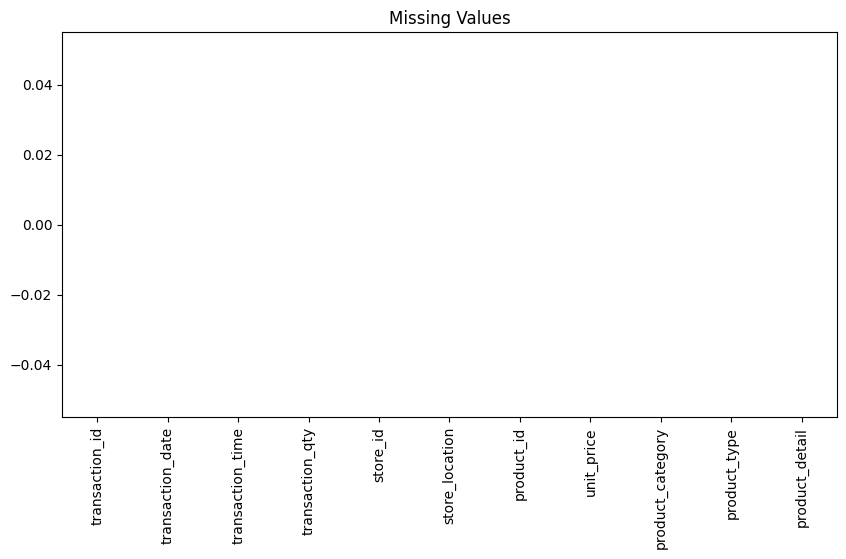

In [6]:
df.isna().sum().plot(kind='bar', figsize=(10, 5), title='Missing Values')


NO NULL VALUES FOUND

## DUPLICATED VALUES ##

In [7]:
df.duplicated().sum()

np.int64(0)

NO DUPLICATES FOUND 

## NOW LETS IDENTIFY NUMERICAL AND CATAGORICAL COLUMNS ##

In [8]:
num_cols=df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols=df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns =", num_cols)
print("")
print("Categorical columns =", cat_cols)



Numerical columns = ['transaction_id', 'transaction_qty', 'store_id', 'product_id', 'unit_price']

Categorical columns = ['transaction_time', 'store_location', 'product_category', 'product_type', 'product_detail']


## DATA UNDERSTANDING , MANIPULATING , TRANSFORMATION AND EDA ##

We do not have a column that possess "Total_Proce"  also we have to calculate the "Profit" and "Loss" for that we need to have a column "Cost_Price".


In [9]:
df['Revenue']=df['transaction_qty']*df['unit_price']
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [10]:
df['cost_per_unit']=df['unit_price']*0.7 ## ASSUMED 70%
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,cost_per_unit
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2.10
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,3.15
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1.40
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17


In [11]:
df['profit_loss']=df['Revenue']-df['cost_per_unit'] 
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,cost_per_unit,profit_loss
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2.10,3.90
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,3.15,5.85
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1.40,0.60
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03


LET'S SEE IF THERE IS ANY -VE VALUE IN PROFIT_LOSS COLUMN...

In [12]:
ng_value=df[df['profit_loss']<0]
print(len(ng_value))

zero_value= df[df['profit_loss']>0]
print(len(zero_value))


0
149116


In [13]:
df.shape

(149116, 14)

WE HAVE NO -VE VALUE IN PROFIT_LOSS COLUMN THIS MEANS THAT WE ONLY HAVE PROFITS AND NO LOSS

LET'S SEE WHICH PRODUCTS ARE THE MOST SELLINGS PRODUCTS     
## MOST SELLING PRODUCT  

<Axes: title={'center': 'MOST SELLING PRODUCT TYPES'}, xlabel='product_type'>

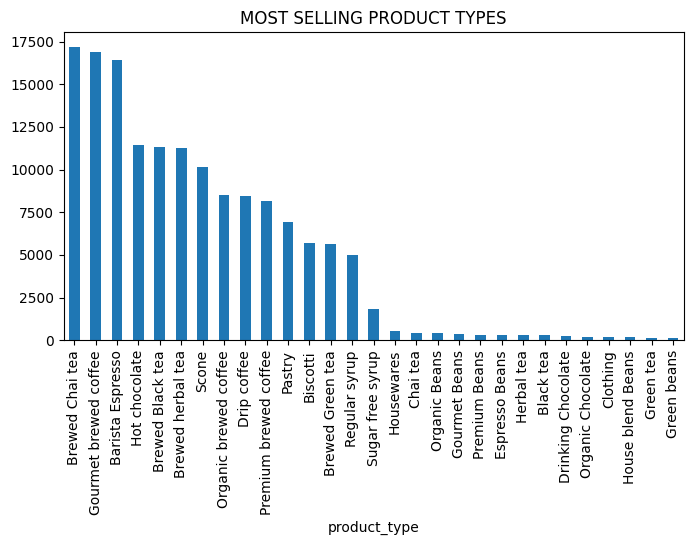

In [14]:
df['product_type'].value_counts().plot(kind='bar', figsize=(8,4),title='MOST SELLING PRODUCT TYPES')


([<matplotlib.patches.Wedge at 0x1aeb0c83770>,
 [Text(-1.0991991778339472, -0.04196626560911468, 'Brewed Chai tea'),
  Text(-0.07876277154251474, -1.0971765700282439, 'Gourmet brewed coffee'),
  Text(1.0746948489854655, -0.2345868316084849, 'Barista Espresso'),
  Text(0.6133077855159877, 0.9131558247229634, 'Hot chocolate'),
  Text(-0.414457946718087, 1.0189330745452458, 'Brewed Black tea')],
 [Text(-0.5995631879094256, -0.022890690332244366, '23.4%'),
  Text(-0.042961511750462575, -0.5984599472881329, '23.1%'),
  Text(0.5861971903557084, -0.1279564536046281, '22.4%'),
  Text(0.3345315193723569, 0.49808499530343453, '15.6%'),
  Text(-0.22606797093713835, 0.5557816770246795, '15.5%')])

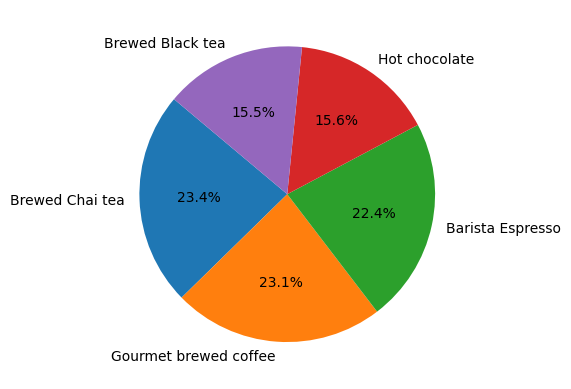

In [15]:
sales_by_product=df.product_type.value_counts().values
sales_by_product1=df.product_type.value_counts().index

plt.pie(sales_by_product[:5], labels=sales_by_product1[:5], autopct='%1.1f%%', startangle=140)




BREWED CHAI TEA , GOURMET BREWED COFFEE , BARISTA ESPRESSEO  ARE THE 3 MOST SELLING PRODUCT TYPES

In [16]:
# Combine transaction_date and transaction_time into a single datetime column
df['datetime'] = pd.to_datetime(df['transaction_date'].dt.strftime('%Y-%m-%d') + ' ' + df['transaction_time'].astype(str), format='%Y-%m-%d %H:%M:%S')

In [17]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'Revenue', 'cost_per_unit', 'profit_loss', 'datetime'],
      dtype='object')

In [18]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,cost_per_unit,profit_loss,datetime
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2.10,3.90,2023-01-01 07:06:11
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03,2023-01-01 07:08:56
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,3.15,5.85,2023-01-01 07:14:04
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1.40,0.60,2023-01-01 07:20:24
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03,2023-01-01 07:22:41


## STORES WITH MOST SALE 

<Axes: title={'center': 'Stores with most Sales'}, xlabel='store_location'>

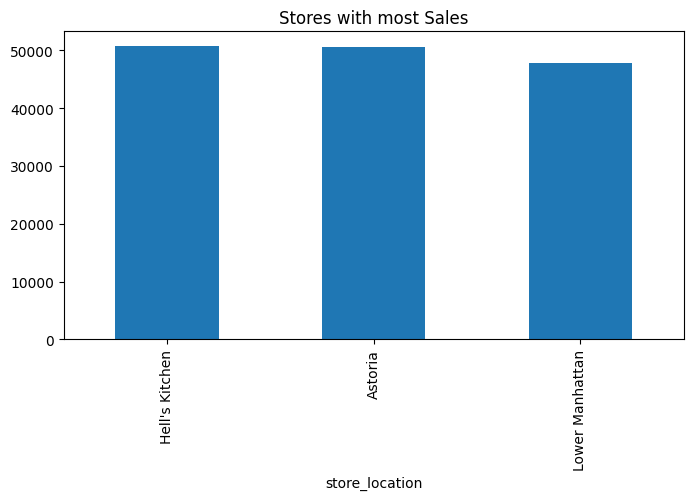

In [19]:
df['store_location'].value_counts().plot(kind='bar',figsize=(8,4) , title='Stores with most Sales')

Hell's Kitchen and Astoria sells alomost same amount of products while Lower Manhattan sell's slightly lower than the other two

## STORES WITH PRODUCTS THEY SELL THE MOST

In [20]:
MSP_by_store=df.groupby(['store_location','product_type'])['transaction_qty'].sum().reset_index()
MSP_by_store=MSP_by_store.loc[MSP_by_store.groupby('store_location')['transaction_qty'].idxmax()]
print(MSP_by_store)

     store_location           product_type  transaction_qty
4           Astoria        Brewed Chai tea             9306
29   Hell's Kitchen       Barista Espresso             9064
71  Lower Manhattan  Gourmet brewed coffee             8563


## Observation ##
1- Most sold product of branch "Astoria" is "Brewed Chai Tea"       
2- Most sold product of branch "Hell's kitchen" is "Barista Espresso"     
3- Most sold product of branch "Lower Manhattan" is "Gourmet brewed coffee"


## STORES WITH PRODUCTS THAT IS SOLD THE LEAST

In [21]:
LSP_by_store=df.groupby(['store_location','product_type'])['transaction_qty'].sum().reset_index()
LSP_by_store=LSP_by_store.loc[LSP_by_store.groupby('store_location')['transaction_qty'].idxmin()]
print(LSP_by_store)

     store_location product_type  transaction_qty
14          Astoria  Green beans               40
37   Hell's Kitchen     Clothing               24
72  Lower Manhattan  Green beans               35


## Observation     
1- Least selling product of branch "Astoria" is "Green beans" .   
2- Least selling product of branch "Hell's Kitchen" is "Clothing" .    
3- Least selling product of branch "Lower Manhattam" is also "Green beans" .    

## LEAST SELLING PRODUCTS

In [22]:
# calculating top 5 least selling product...............
LSP= df.groupby('product_type')['transaction_qty'].sum().sort_values().head(5)
print(LSP)

product_type
Green beans          134
Green tea            159
House blend Beans    183
Clothing             221
Organic Chocolate    221
Name: transaction_qty, dtype: int64


## Observation 
"Green beans" , "Green tea" , "House blend Beans" , "Clothing" and "Organic Chocolate" are the 5 least selling products .

## SALES PER HOUR , PER DAY AND PER MONTH

<Axes: title={'center': 'SALES PER HOUR'}, xlabel='day,hour'>

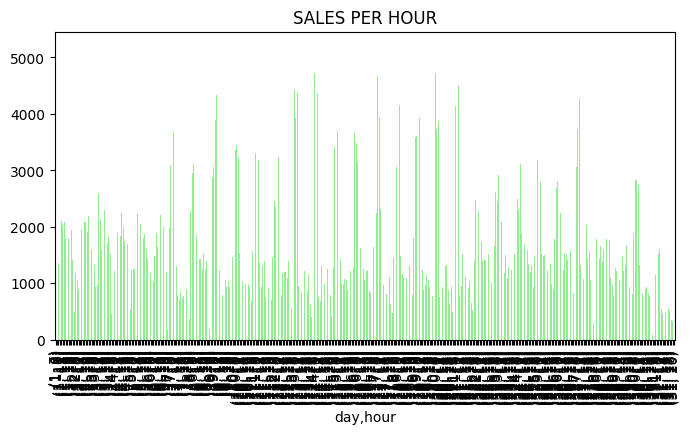

In [23]:
df['hour']=df['datetime'].dt.hour
df['day']=df['datetime'].dt.day
df['month']=df['datetime'].dt.month

sales_per_hour= df.groupby(['day','hour'])['Revenue'].sum()
sales_per_day= df.groupby('day')['Revenue'].sum()
sales_per_month= df.groupby('month')['Revenue'].sum()

sales_per_hour.plot(kind='bar',figsize=(8,4),title='SALES PER HOUR' , color='lightgreen')



<Axes: title={'center': 'SALES PER DAY'}, xlabel='day'>

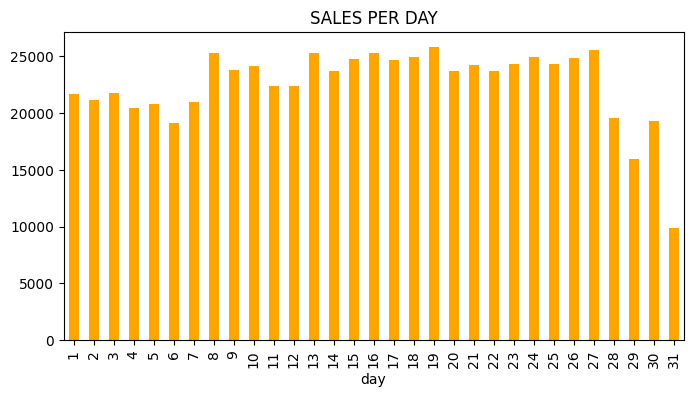

In [24]:
sales_per_day.plot(kind='bar',figsize=(8,4),title='SALES PER DAY', color='orange')

<Axes: title={'center': 'SALES PER MONTH'}, xlabel='month'>

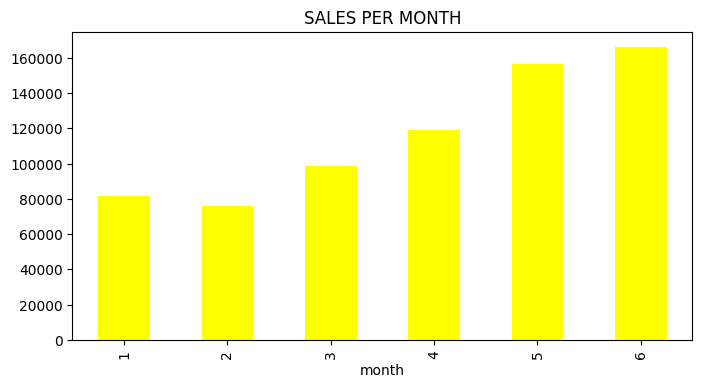

In [25]:
sales_per_month.plot(kind='bar',figsize=(8,4),title='SALES PER MONTH', color='yellow')

## Observation    
1- Sales per hour ranges upto    4000 USD      
2- Sales per day ranges upto     25000 USD     
3- Sales per month  ranges upto  160000 USD   

## PROFIT_LOSS PER HOUR , PER DAY AND PER MONTH

<Axes: title={'center': 'PROFIT PER HOUR'}, xlabel='day,hour'>

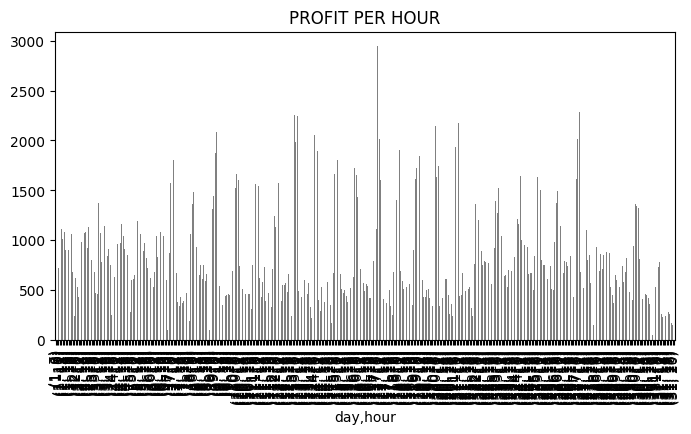

In [26]:
profit_per_hour=df.groupby(['day','hour'])['profit_loss'].sum()
profit_per_hour.plot(kind='bar', figsize=(8,4),title='PROFIT PER HOUR', color='grey')

<Axes: title={'center': 'PROFIT PER DAY'}, xlabel='day'>

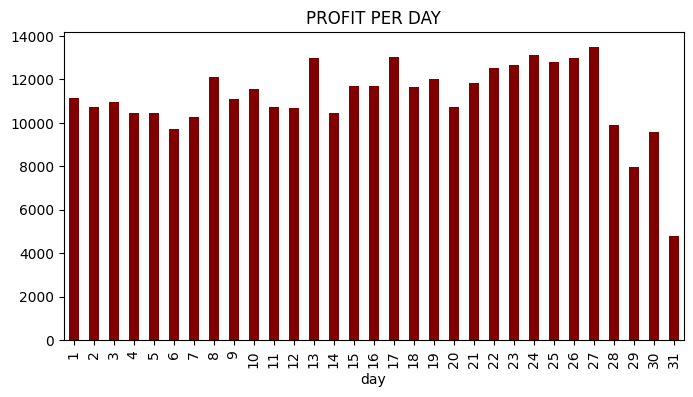

In [27]:
profit_per_day=df.groupby('day')['profit_loss'].sum()
profit_per_day.plot(kind='bar', figsize=(8,4), title='PROFIT PER DAY', color='maroon')

<Axes: title={'center': 'PROFIT PER MONTH'}, xlabel='month'>

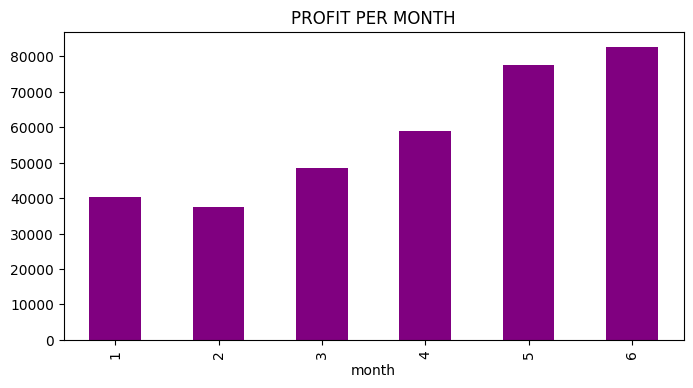

In [28]:
profit_per_month=df.groupby('month')['profit_loss'].sum()
profit_per_month.plot(kind='bar', figsize=(8,4), title='PROFIT PER MONTH', color='purple')

## Observation    
1- Profit per hour ranges upto 3000 USD    
2- Profit per day ranges upto  14000 USD    
3- profit per day ranges upto  80000 USD

In [29]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price,Revenue,cost_per_unit,profit_loss,datetime,hour,day,month
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219,4.686367,2.367554,2.318814,2023-04-16 00:04:47.989404160,11.735790,15.622576,3.988881
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000,0.800000,0.560000,0.240000,2023-01-01 07:06:11,6.000000,1.000000,1.000000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000,3.000000,1.750000,0.900000,2023-03-06 13:37:08,9.000000,8.000000,3.000000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000,3.750000,2.100000,1.125000,2023-04-24 08:24:32.500000,11.000000,16.000000,4.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000,6.000000,2.625000,3.900000,2023-05-30 07:16:13,15.000000,23.000000,5.000000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000,360.000000,31.500000,328.500000,2023-06-30 20:57:19,20.000000,31.000000,6.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723,4.227099,1.861106,3.247389,NaN,3.764662,8.591213,1.673091


In [30]:
num_cols

['transaction_id', 'transaction_qty', 'store_id', 'product_id', 'unit_price']

## DETECTNG OUTLIERS IN NUMERICAL COLUMNS ##

In [31]:
Q1=df[num_cols].quantile(0.25)
Q3=df[num_cols].quantile(0.75)

IQR=Q3-Q1
outliers = (df[num_cols]<(Q1 - 1.5 * IQR)) | (df[num_cols]>(Q3 + 1.5 * IQR)) 

row_with_outliers = df[outliers.any(axis=1)]

print("Number of rows with outliers:", len(row_with_outliers))

Number of rows with outliers: 4233


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2268\287354968.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[feature] for feature in num_cols], labels=num_cols)


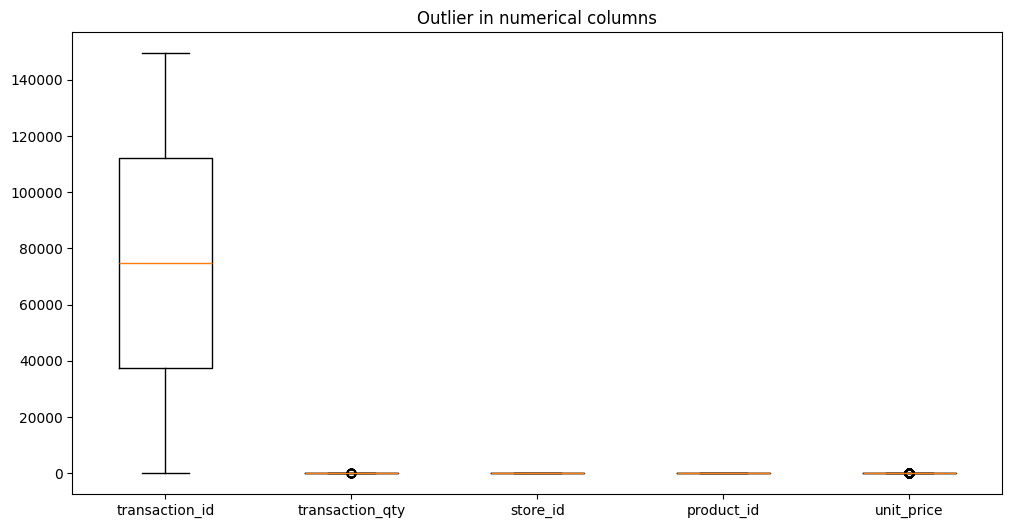

In [32]:

plt.figure(figsize=(12,6))
plt.boxplot([df[feature] for feature in num_cols], labels=num_cols)
plt.title('Outlier in numerical columns')
plt.show()


There are some minor outliers here

## OUTLIERS IN REVENUE

In [33]:
Q1=df['Revenue'].quantile(0.25)
Q3=df['Revenue'].quantile(0.75)
IQR=Q3-Q1
outliers = (df['Revenue']<(Q1 -1.5*IQR))| (df['Revenue']>(Q3 + 1.5*IQR))
outliers_count = outliers.sum()
outliers_count

np.int64(3273)

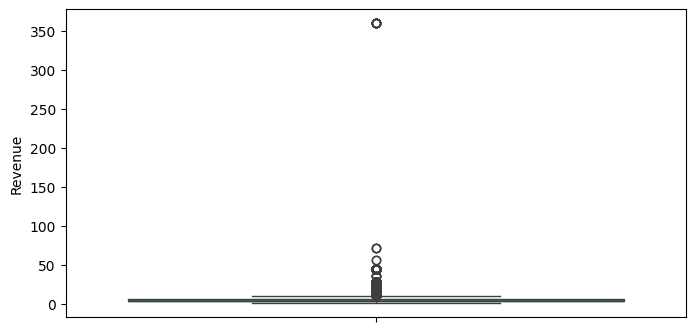

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(df['Revenue'])
plt.show()

## REMOVING OUTLIERS FROM REVENUE ##

In [35]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)

IQR= Q3-Q1

upper_bound = Q3+1.5*IQR 
lower_bound = Q1-1.5*IQR

df_initial = df.copy()

df=df[(df['Revenue']>=lower_bound)& (df['Revenue']<=upper_bound)]



outliers_count = len(df_initial)-len(df)

print("Number of outliers removed:", outliers_count)

Number of outliers removed: 3273


CHECKING OUTLIERS ....

In [36]:
Q1=df['Revenue'].quantile(0.25)
Q3=df['Revenue'].quantile(0.75)
IQR=Q3-Q1
outliers = (df['Revenue']<(Q1 -1.5*IQR))| (df['Revenue']>(Q3 + 1.5*IQR))
outliers_count = outliers.sum()
outliers_count

np.int64(0)

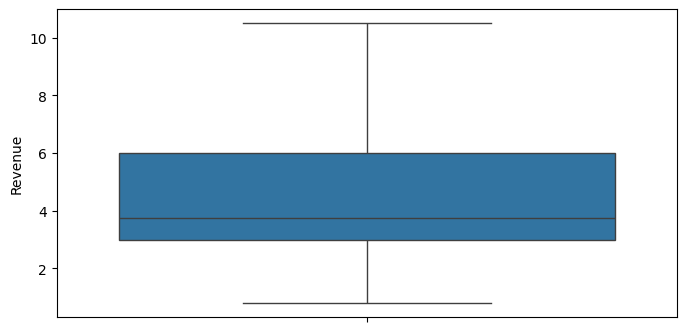

In [37]:
plt.figure(figsize=(8,4))
sns.boxplot(df['Revenue'])
plt.show()

## OUTLIER IN UNIT_PRICE

In [38]:
Q1=df['unit_price'].quantile(0.25)
Q3=df['unit_price'].quantile(0.75)
IQR=Q3-Q1
outliers = (df['unit_price']<(Q1 -1.5*IQR))| (df['unit_price']>(Q3 + 1.5*IQR))
outliers_count = outliers.sum()
outliers_count

np.int64(8366)

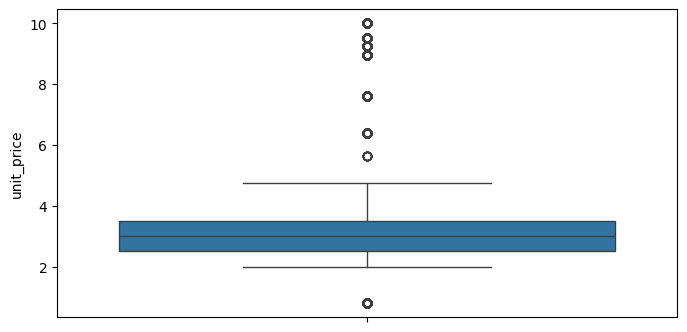

In [39]:
plt.figure(figsize=(8,4))
sns.boxplot(df['unit_price'])
plt.show()

In [40]:
Q1= df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3-Q1
lower_bound= Q1-1.5*IQR
upper_bound= Q3+1.5*IQR
df_initial = df.copy() 
df=df[(df['unit_price']>=lower_bound) & (df['unit_price']<=upper_bound)]
outliers_count = len(df_initial)-len(df)
print("Number of outliers removed",outliers_count)

Number of outliers removed 8366


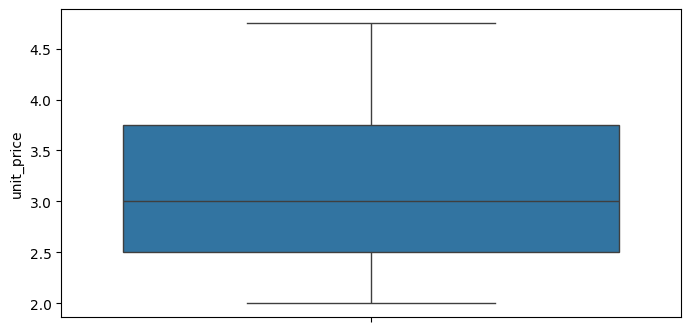

In [41]:
plt.figure(figsize=(8,4))
sns.boxplot(df['unit_price'])
plt.show()

## OUTLIERS IN PROFIT_LOSS COLUMN

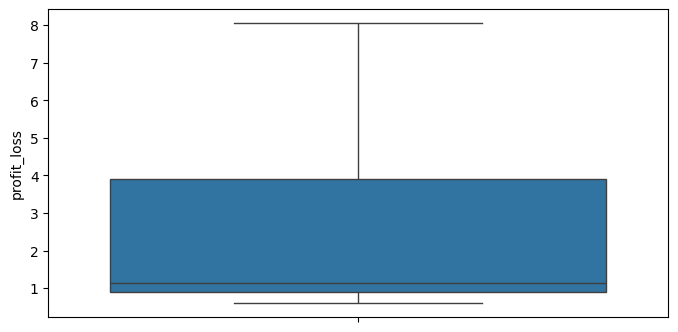

In [42]:
plt.figure(figsize=(8,4))
sns.boxplot(df['profit_loss'])
plt.show()

## OUTLIER IN COST_PER_UNIT

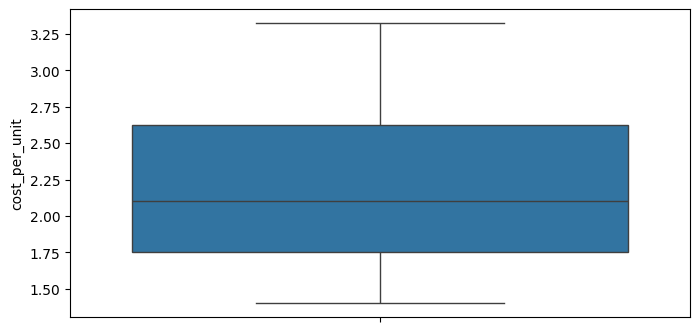

In [43]:
plt.figure(figsize=(8,4))
sns.boxplot(df['cost_per_unit'])
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2268\3120781808.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[feature] for feature in num_cols], labels= num_cols )
C:\Users\Administrator\AppData\Local\Temp\ipykernel_2268\3120781808.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[feature] for feature in num_cols], labels=num_cols)


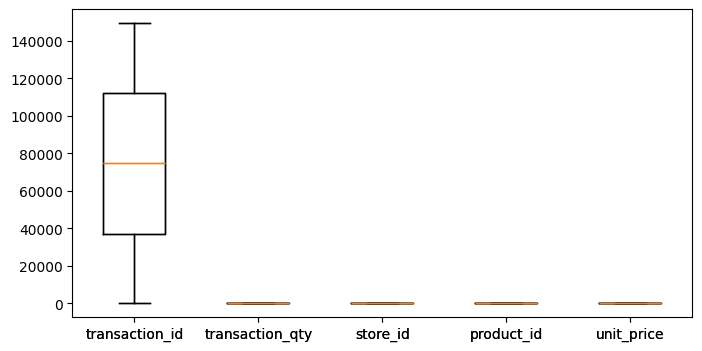

In [44]:
plt.figure(figsize=(8,4))
plt.boxplot([df[feature] for feature in num_cols], labels= num_cols )  
plt.boxplot([df[feature] for feature in num_cols], labels=num_cols)
plt.show()

In [45]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'Revenue', 'cost_per_unit', 'profit_loss', 'datetime', 'hour', 'day',
       'month'],
      dtype='object')

DIVIDING PRODUCT_DETAIL INTO TWO COLUMNS       
PRODUCT_NAME   AND   SIZE

In [46]:
df['size']= df['product_detail'].str.extract(r'\b(Lg|Rg|Sm)\b')

df['product_name']= df['product_detail'].str.replace(r'\b(Lg|Rg|Sm)\b','', regex=True).str.strip()


In [47]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'Revenue', 'cost_per_unit', 'profit_loss', 'datetime', 'hour', 'day',
       'month', 'size', 'product_name'],
      dtype='object')

In [48]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,cost_per_unit,profit_loss,datetime,hour,day,month,size,product_name
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2.10,3.90,2023-01-01 07:06:11,7,1,1,Rg,Ethiopia
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03,2023-01-01 07:08:56,7,1,1,Lg,Spicy Eye Opener Chai
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,3.15,5.85,2023-01-01 07:14:04,7,1,1,Lg,Dark chocolate
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1.40,0.60,2023-01-01 07:20:24,7,1,1,Sm,Our Old Time Diner Blend
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03,2023-01-01 07:22:41,7,1,1,Lg,Spicy Eye Opener Chai


REPLACING "Rg" with "Regular" , "Lg" with "Large" and "Sm" with "Small"

In [49]:
df['size']= df['size'].str.replace('Lg','Large').str.replace('Rg','Regular').str.replace('Sm','Small')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,cost_per_unit,profit_loss,datetime,hour,day,month,size,product_name
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2.10,3.90,2023-01-01 07:06:11,7,1,1,Regular,Ethiopia
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03,2023-01-01 07:08:56,7,1,1,Large,Spicy Eye Opener Chai
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,3.15,5.85,2023-01-01 07:14:04,7,1,1,Large,Dark chocolate
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1.40,0.60,2023-01-01 07:20:24,7,1,1,Small,Our Old Time Diner Blend
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2.17,4.03,2023-01-01 07:22:41,7,1,1,Large,Spicy Eye Opener Chai


Filling missing values with mode of the column "size"

In [50]:
df['size']=df['size'].fillna("Regular")

we dont need the product details anymore as we also have its data in two different columns

In [51]:
df=df.drop(columns=['product_detail'])

In [52]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'Revenue',
       'cost_per_unit', 'profit_loss', 'datetime', 'hour', 'day', 'month',
       'size', 'product_name'],
      dtype='object')

<Axes: title={'center': 'Product Names'}, xlabel='product_name'>

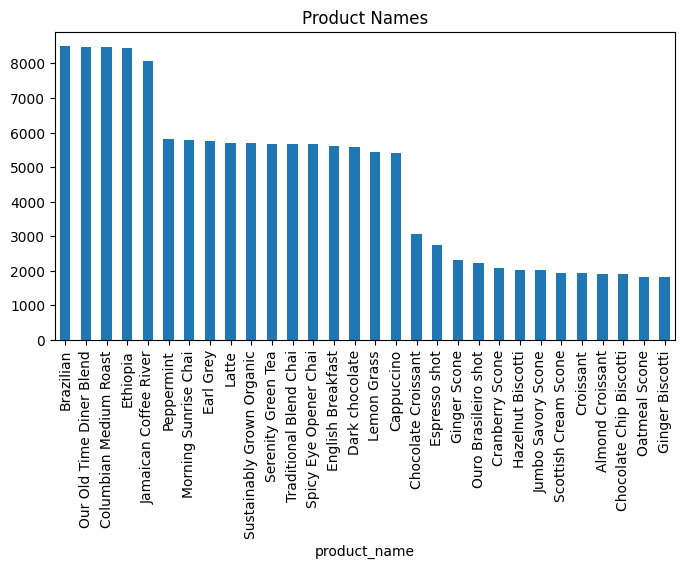

In [53]:
df['product_name'].value_counts().plot(kind='bar', figsize=(8,4),title="Product Names",)

## Observation    
 Brazilian ,our time diner blend , Columbian Medium Roast Ethiopia and jamaican Coffee River are the most selling products.    
    
 

<Axes: xlabel='size'>

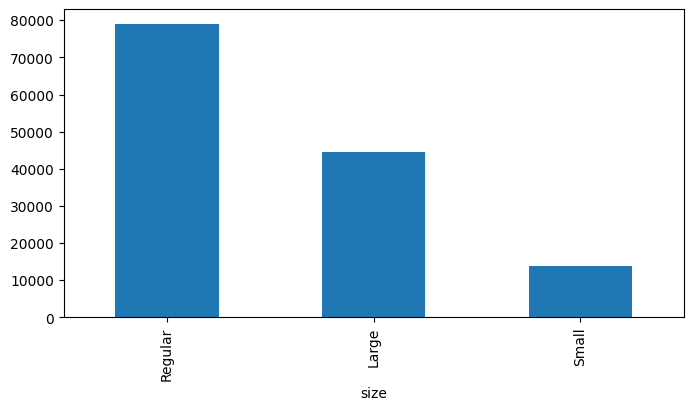

In [54]:
df['size'].value_counts().plot(kind='bar',figsize=(8,4))

## Observation   
1- The most sold Product Size is "Regular".   
2- The least sold Product Size is "Small".

## HOURLY  TRANSACTION 

<Axes: xlabel='day,hour'>

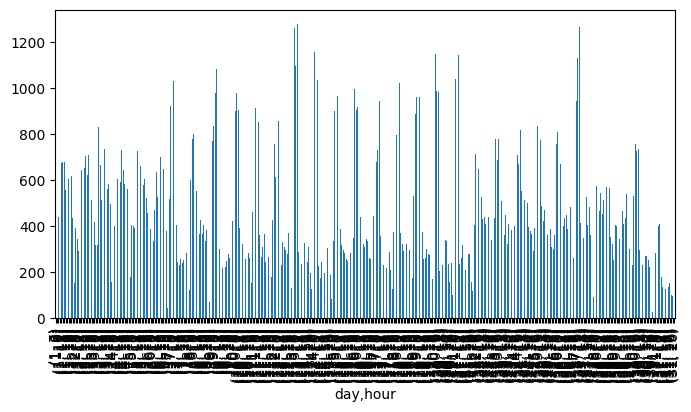

In [55]:
hourly_transaction=df.groupby(['day','hour'])['transaction_qty'].sum()
hourly_transaction.plot(kind='bar', figsize=(8,4))

## Observation    
hourly sales ranges upto 1200

## DAILY TRANSACTION

<Axes: xlabel='day'>

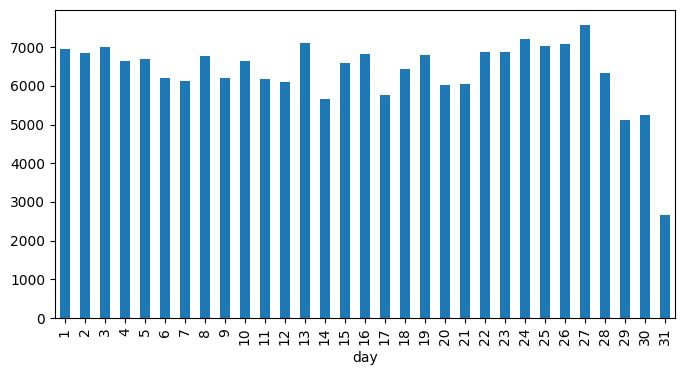

In [56]:
daily_transaction= df.groupby('day')['transaction_qty'].sum()
daily_transaction.plot(kind='bar', figsize=(8,4))

## Observation     
daily transaction ranges  upto 7000

## MONTHLY TRANSACTION   

<Axes: xlabel='month'>

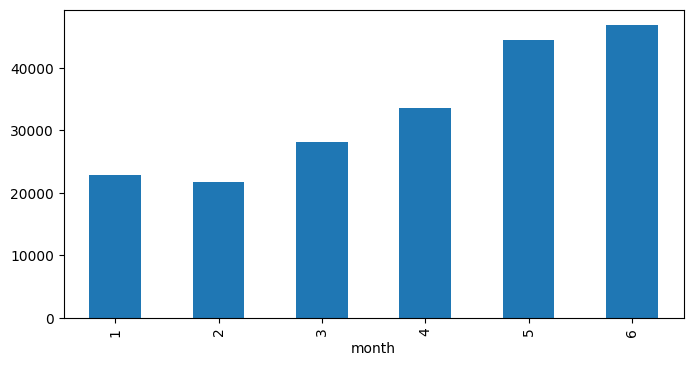

In [57]:
monthly_transaction=df.groupby('month')['transaction_qty'].sum()
monthly_transaction.plot(kind='bar',figsize=(8,4))


## Observation    
Monthly Transaction ranges upto 40000

## PRODUCTS THAT BRINGS THE MOST PROFIT    

<Axes: title={'center': 'TOP 5 PROFITABLE PRODUCTS'}, ylabel='profit_loss'>

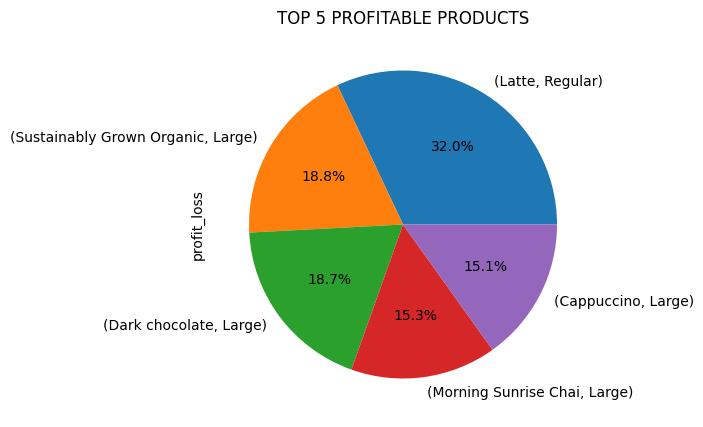

In [58]:
top_5_profitable_products =df.groupby(['product_name','size'])['profit_loss'].sum().sort_values(ascending=False)
top_5_profitable_products.head(5).plot(kind='pie', figsize=(10,5),title='TOP 5 PROFITABLE PRODUCTS', autopct='%1.1f%%')


In [59]:
profit=df['profit_loss'].sum()
print("Total Profit:", profit)

Total Profit: 311855.07700000005


In [60]:
profit_by_top_5= df.groupby('product_name')['profit_loss'].sum().sort_values(ascending=False).head(5)
profit_by_top_5


product_name
Ethiopia                     20629.230
Brazilian                    20525.590
Jamaican Coffee River        20517.345
Sustainably Grown Organic    19033.425
Latte                        18291.375
Name: profit_loss, dtype: float64

In [61]:
profit_by_top_5= 20629.230+ 20525.590+20517.345+ 19033.425+ 18291.375
print("Profit by top 5 products :",profit_by_top_5)

Profit by top 5 products : 98996.965


In [62]:
profit_by_top_5_percentage = (profit_by_top_5/ profit) * 100
profit_by_top_5_percentage

np.float64(31.744541712238977)

# Observation     
31% of the profit is generated by the top 5 selling products

In [63]:
product_summary = df.groupby('product_name').agg({'transaction_qty':'sum', 'Revenue':'mean', 'profit_loss':'sum'}).reset_index()

loss_product = product_summary[product_summary['profit_loss'] <=0]
print("Products with loss:", loss_product[['product_name', 'profit_loss']])

profit_products= product_summary[product_summary['profit_loss']>0]
profit_products

Products with loss: Empty DataFrame
Columns: [product_name, profit_loss]
Index: []


,product_name,transaction_qty,Revenue,profit_loss
0,Almond Croissant,1911,3.766752,2171.439
1,Brazilian,13012,4.446519,20525.590
2,Cappuccino,7980,5.882934,16714.400
3,Chocolate Chip Biscotti,1924,3.568990,2105.538
4,Chocolate Croissant,3096,3.779577,3540.294
5,Columbian Medium Roast,12920,3.813562,17481.450
6,Cranberry Scone,2092,3.282831,2079.657
7,Croissant,1954,3.549860,2110.014
8,Dark chocolate,8453,6.086836,18265.050
9,Earl Grey,8953,4.258036,13488.050


## Predictive Modeling  (PROFIT INCREASE PREDICTION)

In [64]:
df_encoded= pd.get_dummies(df, columns=['product_name'], drop_first=True)

In [67]:
df_encoded.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'Revenue',
       'cost_per_unit', 'profit_loss', 'datetime', 'hour', 'day', 'month',
       'size', 'product_name_Brazilian', 'product_name_Cappuccino',
       'product_name_Chocolate Chip Biscotti',
       'product_name_Chocolate Croissant',
       'product_name_Columbian Medium Roast', 'product_name_Cranberry Scone',
       'product_name_Croissant', 'product_name_Dark chocolate',
       'product_name_Earl Grey', 'product_name_English Breakfast',
       'product_name_Espresso shot', 'product_name_Ethiopia',
       'product_name_Ginger Biscotti', 'product_name_Ginger Scone',
       'product_name_Hazelnut Biscotti', 'product_name_Jamaican Coffee River',
       'product_name_Jumbo Savory Scone', 'product_name_Latte',
       'product_name_Lemon Grass', 'product_name_Morning Sunrise Chai',
       'pr

In [ ]:


feature= df[['transaction_qty', 'store_id', 'unit_price', 'cost_per_unit']]
target =df['profit_loss']

X_train , X_test , y_train ,y_test=train_test_split(feature,target, test_size=0.2, random_state=42)

lm_model=LinearRegression()
lm_model.fit(X_train, y_train)

lm_pred=lm_model.predict(X_test)

mse= mean_squared_error(y_test, lm_pred)
r2=r2_score(y_test, lm_pred)

print('MSE :', mse)
print('R2 :', r2)

MSE : 0.11971288509945413
R2 : 0.9578528153371864



#  Final Conclusion

After analyzing the coffee shop sales dataset, several important insights were discovered:

### Key Findings
- Certain product categories contribute significantly more to overall sales.
- Revenue trends indicate that customer demand varies across product types.
- Most transactions generated positive estimated profit.
- Popular products can be targeted for promotional campaigns and inventory prioritization.

### Business Recommendations
1. Focus marketing efforts on top-performing products.
2. Improve inventory management for high-demand items.
3. Introduce combo offers for frequently purchased products.
4. Track seasonal trends to optimize future sales strategies.
5. Continue collecting transactional data for predictive analytics in the future.

---

#  Future Improvements
Possible future enhancements for this project:
- Time-series forecasting
- Customer segmentation
- Sales prediction models
- Dashboard creation using Power BI or Tableau
- Machine Learning based recommendation systems

---

##  Learning Outcome
This project helped strengthen practical skills in:
- Data cleaning
- Exploratory data analysis
- Feature engineering
- Data visualization
- Business insight generation



#  Author

**Jawad Khan**  
Aspiring Data Analyst / Data Science Enthusiast

This project was created as part of my learning journey in data analytics and exploratory data analysis using Python.
